In [1]:
import torch

# Problem (transformer_accounting):

In [23]:
vocab_size = 50_257
context_length = 1_024
num_layers = 48
d_model = 1_600
num_heads = 25
d_ff = 4_288

In [ ]:

p_embedding = vocab_size * d_model

p_attn = d_model * d_model * 4
p_swiglu = d_model * d_ff * 3
p_rms = d_model * 2

p_transformer = p_attn + p_swiglu + p_rms
p_out = d_model * vocab_size + d_model # rms

p_total = p_embedding + num_layers * p_transformer + p_out
print(f"Total parameters: {p_total = :,}")
print(f"Embedding: {p_embedding = :,}")

print(f"One transformer block: {p_transformer:,}")
print(f"\t{p_attn = :,}")
print(f"\t{p_swiglu = :,}")
print(f"\t{p_rms = :,}")
print(f"Output: {p_out = :,}")


Total parameters:p_total = 1,640,452,800
Embedding: p_embedding = 80,411,200
One transformer block: 30,825,600
	p_attn = 10,240,000
	p_swiglu = 20,582,400
	p_rms = 3,200
Output: p_out = 80,412,800


In [11]:
import torch

# Example configuration
max_seq_len = 100
d_k = 8
theta = 10_000.0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

assert d_k % 2 == 0, "d_k must be even"

# Token positions: (max_seq_len,)
position = torch.arange(
    max_seq_len,
    device=device,
    dtype=torch.float32,
)

# One inverse frequency per pair of embedding dimensions: (d_k // 2,)
inv_freq = 1.0 / (
    theta ** (
        torch.arange(
            0,
            d_k,
            2,
            device=device,
            dtype=torch.float32,
        ) / d_k
    )
)

# Rotation angle for every position and dimension pair:
# (max_seq_len, d_k // 2)
angle = torch.einsum(
    "i,j->ij",
    position,
    inv_freq,
)

cos = torch.cos(angle)
sin = torch.sin(angle)

# Construct:
#
# [[cos, -sin],
#  [sin,  cos]]
#
# for every position and dimension pair.
# Shape: (max_seq_len, d_k // 2, 2, 2)
rotation_for_x = torch.stack(
    (
        torch.stack((cos, -sin), dim=-1),
        torch.stack((sin,  cos), dim=-1),
    ),
    dim=-2,
)

print("position:", position.shape)
print("inv_freq:", inv_freq.shape)
print("angle:", angle.shape)
print("cos:", cos.shape)
print("sin:", sin.shape)
print("rotation:", rotation.shape)

# Inspect the rotation matrix for position 1, coordinate pair 0
print("\nExample rotation matrix:")
print(rotation[1, 0])

position: torch.Size([100])
inv_freq: torch.Size([4])
angle: torch.Size([100, 4])
cos: torch.Size([100, 4])
sin: torch.Size([100, 4])
rotation: torch.Size([16, 4, 2, 2])

Example rotation matrix:
tensor([[ 0.5403, -0.8415],
        [ 0.8415,  0.5403]], device='cuda:0')


In [13]:
rotation_for_x.shape

torch.Size([100, 4, 2, 2])


# Problem (learning_rate_tuning)


In [3]:
import torch
from nn_utils import SGD

In [7]:
n_iter = 10
lrs = [1, 10, 100, 1000]

In [11]:
import matplotlib.pyplot as plt
import numpy as np


Text(0, 0.5, 'Loss')

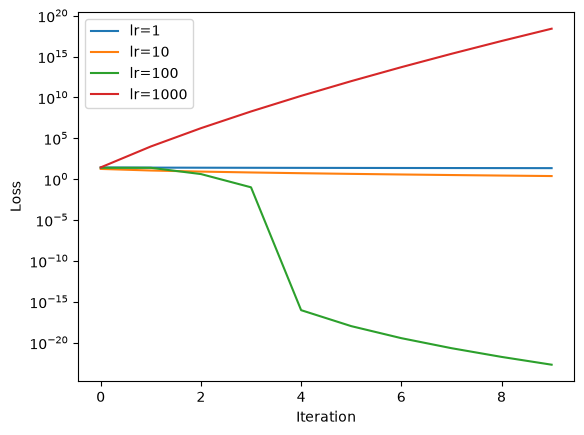

In [16]:
for lr in lrs:
    losses = []
    weights = torch.nn.Parameter(5 * torch.randn((10, 10)))
    opt = SGD([weights], lr=lr)


    for t in range(n_iter):
        opt.zero_grad() # Reset the gradients for all learnable parameters.
        loss = (weights**2).mean() # Compute a scalar loss value.
        losses.append(loss.cpu().item())
        loss.backward() # Run backward pass, which computes gradients.
        opt.step() # Run optimizer step.
    plt.plot(np.arange(n_iter), losses, label=f"lr={lr}")
    plt.legend()
plt.yscale("log")

plt.xlabel("Iteration")
plt.ylabel("Loss")